# 11.3. Attention Scoring Functions

## 📘 Code Along

In [1]:
import math
import torch
from torch import nn

import sys
sys.path.append("../..")
from utils.attention import masked_softmax
from models import DotProductAttention, AdditiveAttention
import utils.plotting as plt_utils

### 11.3.1. Dot Product Attention

### 11.3.2. Convenience Functions

In [2]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.4323, 0.5677, 0.0000, 0.0000],
         [0.4686, 0.5314, 0.0000, 0.0000]],

        [[0.2176, 0.3491, 0.4334, 0.0000],
         [0.2922, 0.4023, 0.3055, 0.0000]]])

In [3]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3747, 0.3500, 0.2752, 0.0000]],

        [[0.5818, 0.4182, 0.0000, 0.0000],
         [0.2648, 0.1904, 0.3183, 0.2265]]])

In [4]:
def check_shape(a, shape):
    """Check the shape of a tensor.

    Defined in :numref:`sec_rnn-scratch`"""
    assert a.shape == shape, \
            f'tensor\'s shape {a.shape} != expected shape {shape}'

In [5]:
Q = torch.ones((2, 3, 4))
K = torch.ones((2, 4, 6))
check_shape(torch.bmm(Q, K), (2, 3, 6))

### 11.3.3. Scaled Dot Product Attention

In [6]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([2, 6])

attention = DotProductAttention(dropout=0.5)
attention.eval()
check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

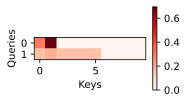

In [7]:
plt_utils.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### 11.3.4. Additive Attention

In [8]:
queries = torch.normal(0, 1, (2, 1, 20))

attention = AdditiveAttention(num_hiddens=8, dropout=0.1)
attention.eval()
check_shape(attention(queries, keys, values, valid_lens), (2, 1, 4))

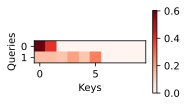

In [9]:
plt_utils.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')